In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Daily Household Transactions.csv")
df.head()

,Date,Mode,Category,Subcategory,Note,Amount,Income/Expense,Currency
0,20/09/2018 12:04:08,Cash,Transportation,Train,2 Place 5 to Place 0,30.0,Expense,INR
1,20/09/2018 12:03:15,Cash,Food,snacks,Idli medu Vada mix 2 plates,60.0,Expense,INR
2,19/09/2018,Saving Bank account 1,subscription,Netflix,1 month subscription,199.0,Expense,INR
3,17/09/2018 23:41:17,Saving Bank account 1,subscription,Mobile Service Provider,Data booster pack,19.0,Expense,INR
4,16/09/2018 17:15:08,Cash,Festivals,Ganesh Pujan,Ganesh idol,251.0,Expense,INR


In [6]:
print(' There are {} rows and {} columns in the dataset.'.format(df.shape[0], df.shape[1]))

 There are 2461 rows and 8 columns in the dataset.


Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2461 entries, 0 to 2460
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            2461 non-null   object 
 1   Mode            2461 non-null   object 
 2   Category        2461 non-null   object 
 3   Subcategory     1826 non-null   object 
 4   Note            1940 non-null   object 
 5   Amount          2461 non-null   float64
 6   Income/Expense  2461 non-null   object 
 7   Currency        2461 non-null   object 
dtypes: float64(1), object(7)
memory usage: 153.9+ KB


In [8]:
df.isnull().sum()

Date                0
Mode                0
Category            0
Subcategory       635
Note              521
Amount              0
Income/Expense      0
Currency            0
dtype: int64

There are 635 records which are null in subcategory and 521 records are null in Note.

In [9]:
df["Mode"].value_counts()

Mode
Saving Bank account 1    1223
Cash                     1046
Credit Card               162
Equity Mutual Fund B       11
Share Market Trading        5
Saving Bank account 2       5
Recurring Deposit           3
Debit Card                  2
Equity Mutual Fund C        1
Equity Mutual Fund A        1
Equity Mutual Fund D        1
Fixed Deposit               1
Name: count, dtype: int64

People mostly uses Saving Bank account 1 mode for Income/Expenses.

In [10]:
df['Subcategory'].fillna('Unknown', inplace=True)
df['Note'].fillna('Unknown', inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_19256\3897287559.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Subcategory'].fillna('Unknown', inplace=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_19256\3897287559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [11]:
df['Amount'] = df['Amount'].astype(float)

In [12]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis

In [13]:
df.dtypes

Date               object
Mode               object
Category           object
Subcategory        object
Note               object
Amount            float64
Income/Expense     object
Currency           object
dtype: object

Graph showing Usage of Modes

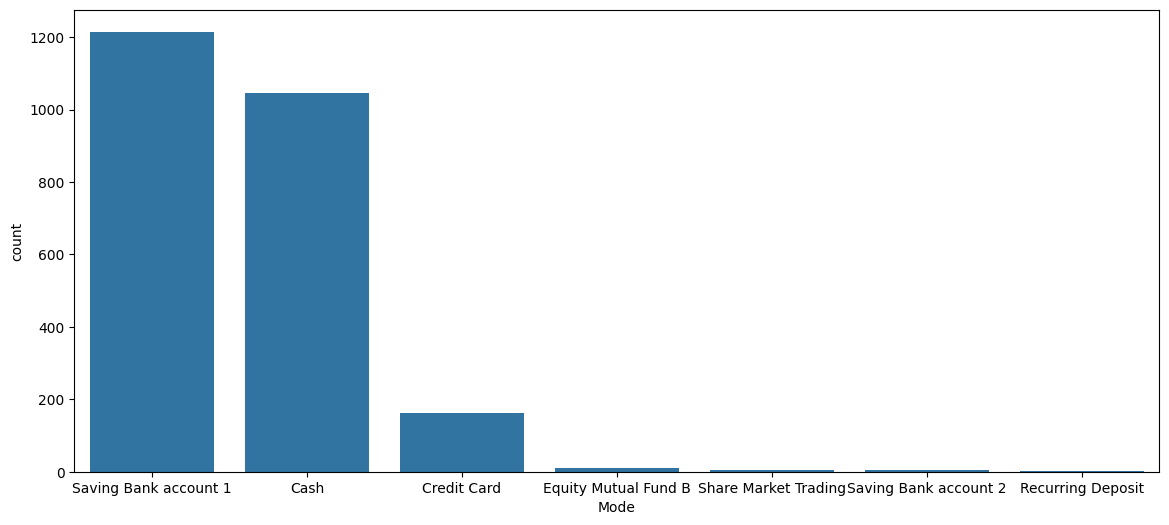

In [39]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x="Mode", order=df["Mode"].value_counts().iloc[:7].index)
plt.show()

In [15]:
df['Category'].value_counts()

Category
Food                         906
Transportation               307
Household                    176
subscription                 143
Other                        126
Investment                   101
Health                        94
Family                        71
Apparel                       47
Salary                        43
Money transfer                43
Recurring Deposit             41
Gift                          30
Public Provident Fund         29
Equity Mutual Fund E          22
Beauty                        22
Gpay Reward                   21
Education                     18
Saving Bank account 1         17
maid                          17
Festivals                     16
Equity Mutual Fund A          14
Equity Mutual Fund F          13
Dividend earned on Shares     12
Interest                      12
Culture                       11
Small Cap fund 2              10
Small cap fund 1              10
Share Market                   8
Life Insurance                 7
M

Graph for Category

<Axes: xlabel='Category', ylabel='count'>

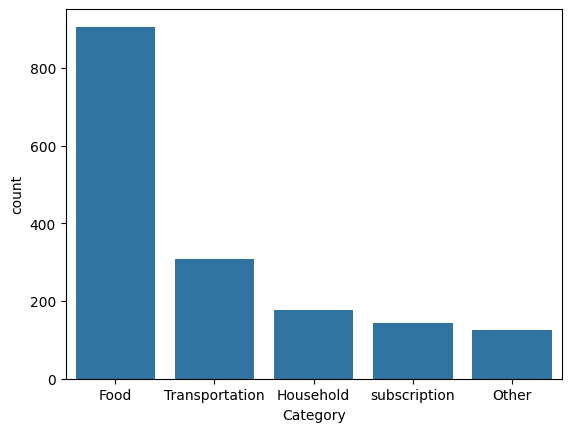

In [16]:
sns.countplot(data=df, x='Category', order=df['Category'].value_counts().iloc[:5].index)

In [17]:
df['Subcategory'].unique()

array(['Train', 'snacks', 'Netflix', 'Mobile Service Provider',
       'Ganesh Pujan', 'Tata Sky', 'auto', 'Unknown', 'Grocery', 'Lunch',
       'Milk', 'Pocket money', 'Laundry', 'breakfast', 'Dinner', 'Sweets',
       'Kirana', 'Ice cream', 'curd', 'Biscuits', 'Rajgira ladu',
       'Navratri', 'train', 'Tea', 'flour mill', 'Appliances',
       'home decor', 'grooming', 'Health', 'Clothing', 'clothes', 'Home',
       'chocolate', 'Medicine', 'Eating out', 'Movie', 'vegetables',
       'fruits', 'Potato', 'Onions', 'Taxi', 'Hardware', 'Eggs', 'Bread',
       'Petrol', 'Hospital', 'Mahanagar Gas', 'Lab Tests', 'Bus',
       'Travels', 'Kitchen', 'Footwear', 'Entry Fees', 'gadgets',
       'Accessories', 'misc', 'Stationary', 'Newspaper', 'Toiletries',
       'Bike', 'beverage', 'makeup', 'Books', 'Holi', 'Courier',
       'Leisure', 'Updation', 'Amazon Prime', 'Edtech Course', 'Hotstar',
       'Diwali', 'Wifi Internet Service', 'Trip', 'Furniture', 'Water',
       'Cable TV', 'medicin

Graph showing Subcategory

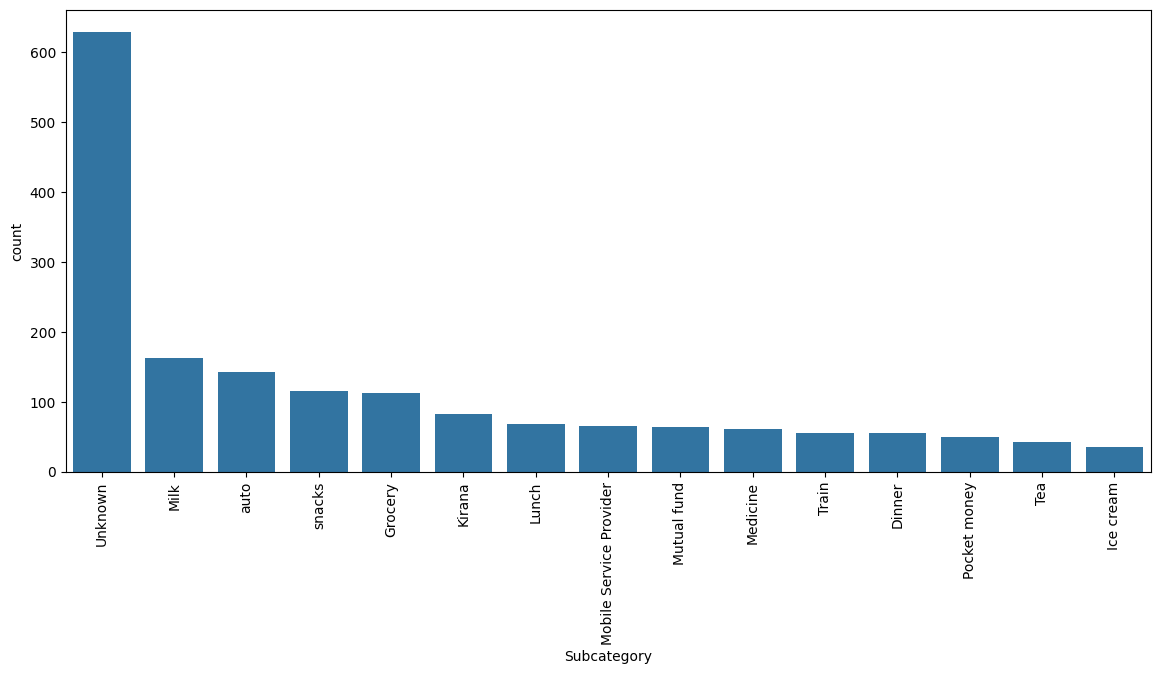

In [31]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='Subcategory', order=df['Subcategory'].value_counts().iloc[:15].index)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Income/Expense', ylabel='count'>

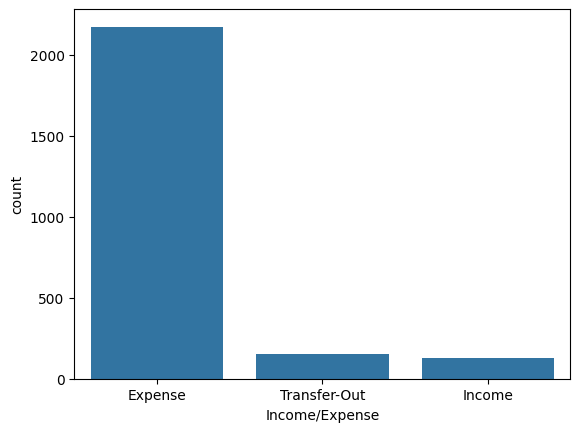

In [19]:
sns.countplot(data=df, x="Income/Expense")

In [20]:
df['Note'].nunique()

1058

In [21]:
df['Currency'].value_counts()

Currency
INR    2452
Name: count, dtype: int64

Graph Showing Amount for some Category and Subcategory

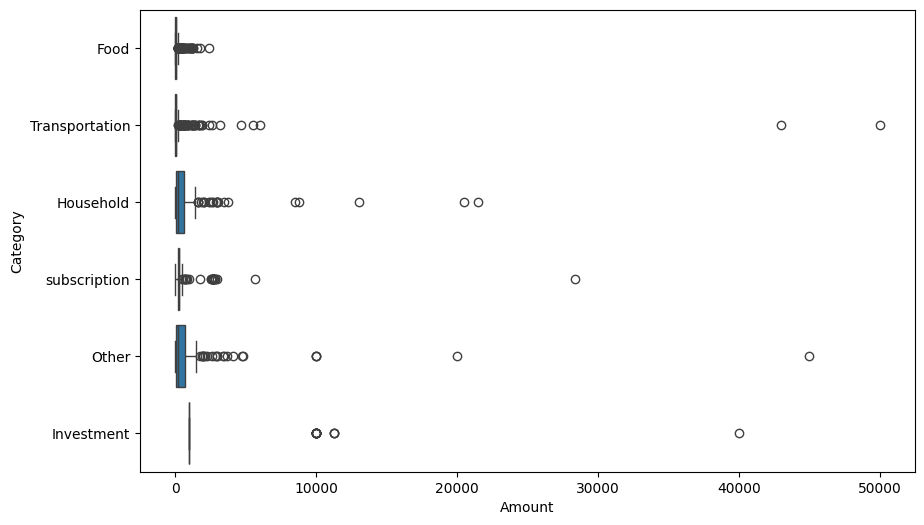

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Amount', y='Category', order=df['Category'].value_counts().iloc[:6].index)
plt.show()

Amount spend in Subcategory

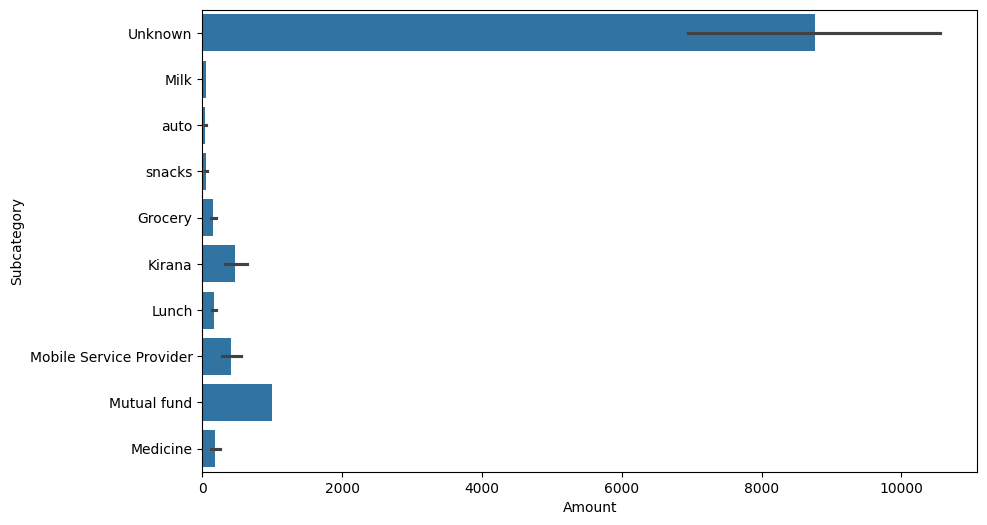

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Amount', y='Subcategory', order=df['Subcategory'].value_counts().iloc[:10].index)
plt.show()

Graph showing Income/Expense

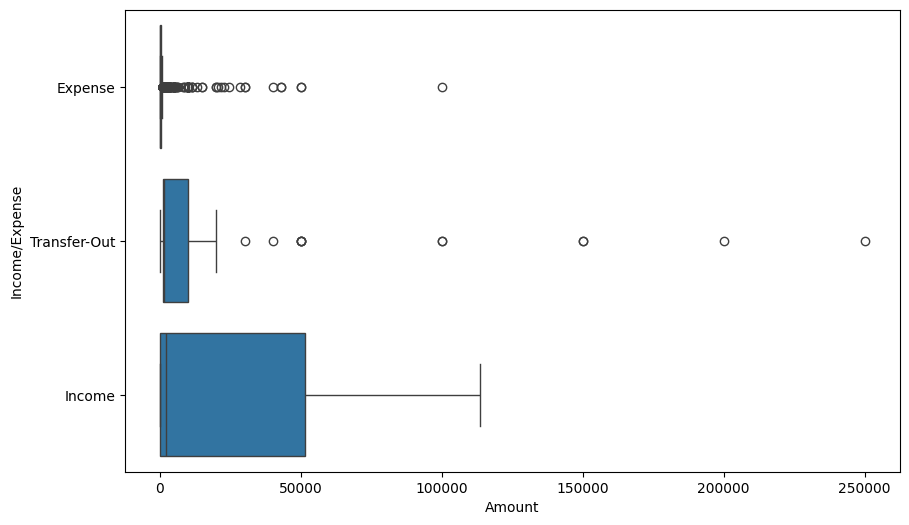

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Amount', y='Income/Expense')
plt.show()

Mode of Income/Expense

<Axes: xlabel='Income/Expense', ylabel='Mode'>

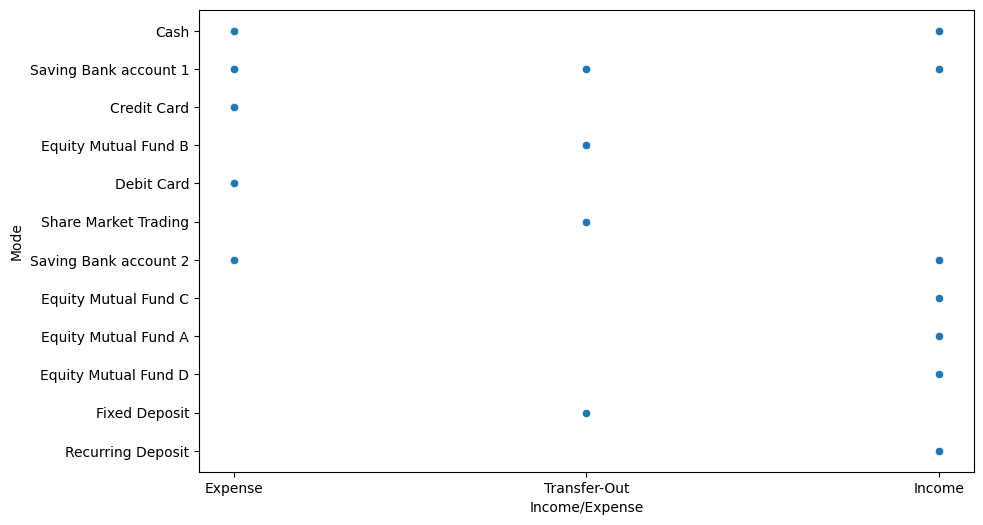

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Income/Expense', y='Mode')

1. Income is saved in Cash, Saving Bank account 1 and 2, Equity Mutual Fund A, C, D and Recurring Deposit.
2. Transfer-Out is from Saving Bank account 1, Equity Mutual Fund B, Share Market Trading, Fixed Deposit.
3. Expense is spend from Cash, Saving Bank account 1, Credit Card, Debit Card and Saving Bank account 2.